Try using a denoising autoencoder to pretrain an image classifier. You can use MNIST (the simplest option), or a more complex image dataset such as CIFAR10 if you want a bigger challenge. Regardless of the dataset you’re using, follow these steps:
- Split the dataset into a training set and a test set. Train a deep denoising autoencoder on the full training set.
- Check that the images are fairly well reconstructed. Visualize the images that most activate each neuron in the coding layer.
- Build a classification DNN, reusing the lower layers of the autoencoder. Train it using only 500 images from the training set. Does it perform better with or without pretraining?


In [59]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms.v2 as T
import torchmetrics
import matplotlib.pyplot as plt
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from collections import namedtuple

device = 'cuda'

In [32]:
ToTensor = T.Compose([T.ToImage(), T.ToDtype(dtype=torch.float32, scale=True)])

dataset = torchvision.datasets.CIFAR10(root='datas', train=True, transform=ToTensor)
train_dataset, valid_dataset = torch.utils.data.random_split(dataset, lengths=[45000, 5000])

class AEdataset(Dataset):
    def __init__(self, dataset):
        super().__init__()
        self.dataset = dataset
    
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, index):
        x, _ = self.dataset[index]
        return x, x
    

train_loader = DataLoader(AEdataset(train_dataset), batch_size=32, shuffle=True)
valid_loader = DataLoader(AEdataset(valid_dataset), batch_size=32)

In [3]:
def eval_model(model, metric, valid_loader):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for X_batch, y_batch in valid_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            if isinstance(y_pred, tuple):
                y_pred = y_pred.output
            metric.update(y_pred, y_batch)
            
    return metric.compute()

def train_model(model, optimizer, criterion, metric, train_loader, valid_loader, n_epochs, 
                factor=0.5, patience=2, epoch_callback=None, temperature_decrease=False, train_encoder=True):
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', factor, patience)
    history = {'train_loss':[], 'train_metrics':[], 'valid_metrics':[]}
    
    for epoch in range(n_epochs):
        total_loss = 0.0
        model.train()
        metric.reset()
        
        if train_encoder == False:
            model.encoder.eval()
            for p in model.encoder.parameters():
                p.requires_grad = False
                
        if epoch_callback is not None:
            epoch_callback(model, epoch)
            
        if temperature_decrease == True:
            model.temperature = 1 - 0.7 * (epoch/n_epochs)
            
        for index, (X_batch, y_batch) in enumerate(train_loader):
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            optimizer.zero_grad()
            
            if isinstance(y_pred, tuple):
                y_pred = y_pred.output
            metric.update(y_pred, y_batch)
            train_metric = metric.compute().item()
            print(f'\rBatch: {index + 1}/{len(train_loader)}', end="")
            print(f', loss={total_loss/(index+1):.3f}', end="")
            print(f', {train_metric=:.2f}', end="")
            
        history['train_loss'].append(total_loss/len(train_loader))
        history['train_metrics'].append(train_metric)
        val_metric = eval_model(model, metric, valid_loader)
        history['valid_metrics'].append(val_metric)
        
        scheduler.step(val_metric)
        print(f'\rEpoch: {epoch+1}/{n_epochs}\tTrain loss: {history["train_loss"][-1]:.3f}\tTrain metrics: {history['train_metrics'][-1]:.3f}\tValid metrics: {history['valid_metrics'][-1]:.3f}')
    
    return history

In [4]:
encoder = nn.Sequential(nn.Flatten(), nn.Linear(32*32*3, 1024), nn.ReLU(),
                        nn.Linear(1024, 512), nn.ReLU(), nn.Linear(512, 512), nn.ReLU(),
                        nn.Linear(512, 256), nn.ReLU())
decoder = nn.Sequential(nn.Linear(256, 512), nn.ReLU() , nn.Linear(512, 512), nn.ReLU(),
                        nn.Linear(512, 1024), nn.ReLU(),
                        nn.Linear(1024, 32*32*3), nn.Sigmoid(), nn.Unflatten(dim=1, unflattened_size=(3, 32, 32)))
denoising_autoencoder = nn.Sequential(encoder, decoder).to(device)

nadam = torch.optim.NAdam(denoising_autoencoder.parameters())
mse = nn.MSELoss()
rmse = torchmetrics.MeanSquaredError(squared=False).to(device)

history = train_model(denoising_autoencoder, nadam, mse, rmse, train_loader, valid_loader, 25)

Epoch: 1/25	Train loss: 0.049	Train metrics: 0.221	Valid metrics: 0.193
Epoch: 2/25	Train loss: 0.037	Train metrics: 0.193	Valid metrics: 0.195
Epoch: 3/25	Train loss: 0.034	Train metrics: 0.186	Valid metrics: 0.181
Epoch: 4/25	Train loss: 0.033	Train metrics: 0.181	Valid metrics: 0.181
Epoch: 5/25	Train loss: 0.033	Train metrics: 0.181	Valid metrics: 0.181
Epoch: 6/25	Train loss: 0.032	Train metrics: 0.180	Valid metrics: 0.180
Epoch: 7/25	Train loss: 0.032	Train metrics: 0.180	Valid metrics: 0.180
Epoch: 8/25	Train loss: 0.032	Train metrics: 0.180	Valid metrics: 0.180
Epoch: 9/25	Train loss: 0.032	Train metrics: 0.180	Valid metrics: 0.179
Epoch: 10/25	Train loss: 0.032	Train metrics: 0.180	Valid metrics: 0.180
Epoch: 11/25	Train loss: 0.032	Train metrics: 0.180	Valid metrics: 0.180
Epoch: 12/25	Train loss: 0.032	Train metrics: 0.180	Valid metrics: 0.179
Epoch: 13/25	Train loss: 0.032	Train metrics: 0.180	Valid metrics: 0.179
Epoch: 14/25	Train loss: 0.032	Train metrics: 0.180	Valid me

In [4]:
def plot_reconstruction(model, dataset, index=0):
    fig = plt.figure(figsize=(6, 6))

    an_image = dataset[index][0].permute(1, 2, 0)
    plt.subplot(1, 2, 1)
    plt.imshow(an_image)
    plt.axis('off')

    model.eval()
    with torch.no_grad():
        r_image = model(an_image.view(1, 32*32*3).to(device))
        
    if isinstance(r_image, tuple):
        r_image = r_image.output
        
    r_image = r_image.view(3, 32, 32)
    r_image = r_image.permute(1, 2, 0)
    r_image = r_image.cpu()
    r_image = torch.clamp(r_image, 0, 1)
    plt.subplot(1, 2, 2)
    plt.imshow(r_image)
    plt.axis('off')
    plt.show()

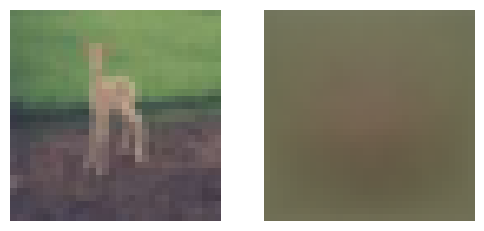

In [ ]:
plot_reconstruction(denoising_autoencoder, valid_dataset, 0)

In [94]:
denoising_autoencoder.eval()
encoder.eval()
activations = encoder(valid_dataset[7][0].view(1, 3, 32, 32).to(device))
activation = encoder(valid_dataset[8][0].view(1, 3, 32, 32).to(device))
activations = torch.cat([activations, activations], dim=0)
activations.argmax(dim=1)

tensor([207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207,
        207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207,
        207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207,
        207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207,
        207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207,
        207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207,
        207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207,
        207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207,
        207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207,
        207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207,
        207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207,
        207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207,
        207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 2

In [ ]:
def neuron_activation(encoder, dataset):
    encoder.eval()
    activations = encoder(dataset[0][0].view(1, 3, 32, 32).to(device))
    for i in range(len(dataset)):
        activations = torch.cat([activations, encoder(dataset[i][0].view(1, 3, 32, 32).to(device))])
        
    return activations

activations = neuron_activation(encoder, valid_dataset)

def neuron_favorite_image(activations):
    neuron_and_image_indexes = []
    only_images = []
    activations = activations.argmax(dim=0)
    for i in range(len(activations)):
        if activations[i].item() != 0 and activations[i].item() not in only_images:
            neuron_and_image_indexes.append((i, activations[i].item()))
            only_images.append(activations[i].item())
            
    return neuron_and_image_indexes

NI = neuron_favorite_image(activations)
    

[(1, 3407), (3, 1257), (48, 475), (69, 1085), (99, 187), (117, 2642), (118, 50), (163, 1533), (203, 2769), (209, 2606), (222, 3501), (227, 3399)]


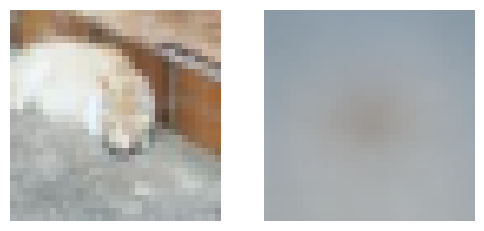

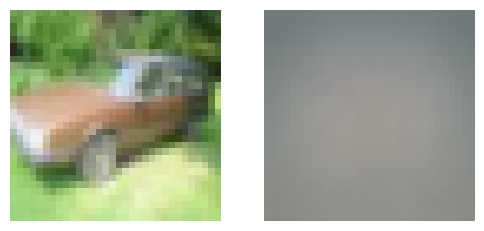

In [7]:
#only 2 neurons work! better to build sparse model
print(NI)
plot_reconstruction(denoising_autoencoder, valid_dataset, 2524)
plot_reconstruction(denoising_autoencoder, valid_dataset, 2841)

In [7]:
SparseOutput = namedtuple("SparseOutput", ['output', 'codings'])

class SparseDenoisingAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(nn.Flatten(), nn.Linear(32*32*3, 1024), nn.ReLU(),
                                nn.Linear(1024, 512), nn.ReLU(), nn.Linear(512, 512), nn.ReLU(),
                                nn.Linear(512, 256), nn.Sigmoid())
        self.decoder = nn.Sequential(nn.Linear(256, 512), nn.ReLU() , nn.Linear(512, 512), nn.ReLU(),
                                nn.Linear(512, 1024), nn.ReLU(),
                                nn.Linear(1024, 32*32*3), nn.Sigmoid(), nn.Unflatten(dim=1, unflattened_size=(3, 32, 32)))

    def forward(self, X):
        encodings = self.encoder(X)
        outputs = self.decoder(encodings)
        return SparseOutput(outputs, encodings)

sparse_model = SparseDenoisingAutoencoder().to(device)
nadam = torch.optim.NAdam(sparse_model.parameters())
rmse = torchmetrics.MeanSquaredError(squared=False).to(device)
mse = nn.MSELoss()

def mse_sparsity_loss(y_pred, y_target, target_sparsity=0.1, kl_weight=0.001, eps=1e-8):
    p = torch.tensor(target_sparsity, device=y_pred.codings.device)
    q = torch.clamp(y_pred.codings.mean(dim=0), eps, 1-eps)
    kl_div = p*torch.log(p/q) + (1-p)*torch.log((1-p)/(1-q))
    return mse(y_pred.output, y_target) + kl_weight * kl_div.sum()

history = train_model(sparse_model, nadam, mse_sparsity_loss, rmse, train_loader, valid_loader, 30)

Epoch: 1/30	Train loss: 0.047	Train metrics: 0.212	Valid metrics: 0.199
Epoch: 2/30	Train loss: 0.038	Train metrics: 0.194	Valid metrics: 0.193
Epoch: 3/30	Train loss: 0.034	Train metrics: 0.184	Valid metrics: 0.183
Epoch: 4/30	Train loss: 0.033	Train metrics: 0.180	Valid metrics: 0.180
Epoch: 5/30	Train loss: 0.031	Train metrics: 0.176	Valid metrics: 0.175
Epoch: 6/30	Train loss: 0.030	Train metrics: 0.173	Valid metrics: 0.173
Epoch: 7/30	Train loss: 0.028	Train metrics: 0.167	Valid metrics: 0.169
Epoch: 8/30	Train loss: 0.027	Train metrics: 0.165	Valid metrics: 0.166
Epoch: 9/30	Train loss: 0.027	Train metrics: 0.165	Valid metrics: 0.166
Epoch: 10/30	Train loss: 0.027	Train metrics: 0.164	Valid metrics: 0.165
Epoch: 11/30	Train loss: 0.027	Train metrics: 0.164	Valid metrics: 0.164
Epoch: 12/30	Train loss: 0.027	Train metrics: 0.163	Valid metrics: 0.164
Epoch: 13/30	Train loss: 0.027	Train metrics: 0.163	Valid metrics: 0.164
Epoch: 14/30	Train loss: 0.027	Train metrics: 0.163	Valid me

In [9]:
sparse_activations = neuron_activation(sparse_model.encoder, valid_dataset)
sparse_ni = neuron_favorite_image(sparse_activations)
print(sparse_ni)
print(len(sparse_ni))

[(0, 2642), (1, 417), (2, 475), (6, 4119), (7, 2151), (8, 3639), (9, 1755), (10, 2397), (12, 3365), (13, 864), (16, 1660), (19, 3162), (20, 3433), (23, 3327), (26, 3280), (33, 1247), (35, 2061), (39, 1533), (42, 4372), (45, 3256), (49, 3584), (52, 2840), (56, 4614), (59, 809), (60, 3372), (65, 2656), (66, 4937), (73, 1979), (78, 2489), (79, 4838), (82, 3823), (91, 4438), (95, 4012), (103, 3149), (115, 2470), (119, 1236), (129, 2254), (138, 999), (139, 4489), (152, 476), (166, 313), (190, 4082), (196, 2207), (201, 683), (204, 1198), (209, 4590), (225, 4653), (228, 734), (230, 2418), (248, 967), (249, 2443), (250, 98), (255, 4618)]
53


In [10]:
#all neurons work (I guess)
sparse_activations.argmax(dim=0)

tensor([2642,  417,  475, 2642,  417, 2642, 4119, 2151, 3639, 1755, 2397, 2642,
        3365,  864, 2151, 3639, 1660, 3639, 3639, 3162, 3433, 2642, 3639, 3327,
        2151,  864, 3280,  864, 2151, 3280, 2642,  475, 3639, 1247, 3639, 2061,
        3639, 3327, 3639, 1533, 4119, 1533, 4372, 3639,  417, 3256, 4119, 2397,
        3365, 3584, 2642, 2642, 2840, 3639, 2642, 3639, 4614, 3639,  475,  809,
        3372, 2642, 3639, 2151, 2642, 2656, 4937, 2642, 3639, 3433, 2642, 3639,
        3365, 1979, 2642,  864, 4119, 2656, 2489, 4838, 2397, 2397, 3823,  475,
        4119, 3327, 2642, 3639, 2642,  864, 2151, 4438, 3639, 3256, 4119, 4012,
        3639, 3433, 2642, 2642, 3639, 3639, 2151, 3149, 3639, 2642,  809, 3639,
        2642, 2151, 2642, 4614,  864, 4119, 2151, 2470, 2151, 2151, 2642, 1236,
        2642, 1533, 2642, 4372, 2151, 3639,  475, 4119, 2642, 2254, 3372, 3823,
        2642, 3639, 2642, 2151, 2642, 3256,  999, 4489, 3327, 3639, 2151, 3372,
        3280, 3639, 1660, 3639, 2642, 21

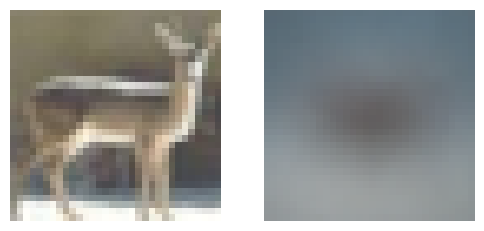

In [11]:
#still very blury
plot_reconstruction(sparse_model, valid_dataset, 1900)

classification task

In [9]:
cls_train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
cls_valid_loader = DataLoader(valid_dataset, batch_size=32)

class EncoderCls(nn.Module):
    def __init__(self, encoder, num_classes):
       super().__init__()
       self.encoder = encoder
       self.dnn = nn.Sequential(nn.Linear(256, 128), nn.ReLU(), nn.BatchNorm1d(128),
                          nn.Dropout(0.1), nn.Linear(128, num_classes)).to(device)
       
    def forward(self, X):
        self.encoder.eval()
        with torch.no_grad():
            features = self.encoder(X)
        return self.dnn(features)
        
        
cls_model = EncoderCls(sparse_model.encoder, 10).to(device)


cls_model.eval()
with torch.no_grad():
    for X, y in cls_valid_loader:
        probas = cls_model(X.to(device)).argmax(dim=1)
        break
    
print(probas)
print(y)
print(torch.stack([y[i]==probas[i] for i in range(len(y))]).float().mean())

tensor([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2], device='cuda:0')
tensor([2, 1, 1, 8, 7, 8, 8, 1, 2, 7, 0, 5, 2, 6, 8, 6, 9, 7, 3, 4, 1, 9, 4, 7,
        0, 6, 6, 7, 7, 2, 7, 2])
tensor(0.1562, device='cuda:0')


In [56]:
class RestrictedDataset(Dataset):
    def __init__(self, dataset, num_instances):
        self.dataset = [dataset[i] for i in range(num_instances)]
        
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, index):
        return self.dataset[index][0], self.dataset[index][1]

In [49]:
restricted_loader = DataLoader(RestrictedDataset(train_dataset, 500), batch_size=32, shuffle=True)
nadam = torch.optim.NAdam(params=cls_model.parameters())
accuracy = torchmetrics.Accuracy(task='multiclass', num_classes=10).to(device)
xentropy = nn.CrossEntropyLoss()

history = train_model(cls_model, nadam, xentropy, accuracy, restricted_loader, cls_valid_loader, 500, train_encoder=False)

Epoch: 1/500	Train loss: 2.236	Train metrics: 0.184	Valid metrics: 0.152
Epoch: 2/500	Train loss: 2.083	Train metrics: 0.252	Valid metrics: 0.210
Epoch: 3/500	Train loss: 2.049	Train metrics: 0.270	Valid metrics: 0.240
Epoch: 4/500	Train loss: 2.023	Train metrics: 0.274	Valid metrics: 0.242
Epoch: 5/500	Train loss: 1.981	Train metrics: 0.300	Valid metrics: 0.240
Epoch: 6/500	Train loss: 1.993	Train metrics: 0.274	Valid metrics: 0.243
Epoch: 7/500	Train loss: 1.974	Train metrics: 0.304	Valid metrics: 0.256
Epoch: 8/500	Train loss: 1.973	Train metrics: 0.290	Valid metrics: 0.201
Epoch: 9/500	Train loss: 1.979	Train metrics: 0.288	Valid metrics: 0.234
Epoch: 10/500	Train loss: 1.956	Train metrics: 0.262	Valid metrics: 0.230
Epoch: 11/500	Train loss: 1.944	Train metrics: 0.288	Valid metrics: 0.237
Epoch: 12/500	Train loss: 1.916	Train metrics: 0.306	Valid metrics: 0.249
Epoch: 13/500	Train loss: 1.901	Train metrics: 0.302	Valid metrics: 0.244
Epoch: 14/500	Train loss: 1.855	Train metrics: 

In [ ]:
#convolutional sparse denoising ae
SparseOutput = namedtuple("SparseOutput", ['output', 'codings'])
#input [3x32x32]
class ConvAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(nn.Dropout(0.25), nn.Conv2d(3, 16, kernel_size=3, padding='same'), nn.ReLU(), nn.MaxPool2d(kernel_size=2), #[16x16x16]
                                    nn.Conv2d(16, 32, kernel_size=3, padding='same'), nn.ReLU(), nn.MaxPool2d(kernel_size=2), #[32x8x8]
                                    nn.Conv2d(32, 64, kernel_size=3, padding='same'), nn.ReLU(), nn.MaxPool2d(kernel_size=2), #[64x4x4]
                                    nn.Conv2d(64, 128, kernel_size=3, padding='same'), nn.ReLU(), nn.MaxPool2d(kernel_size=2), #[128x2x2]
                                    nn.Conv2d(128, 256, kernel_size=2, padding='same'), nn.ReLU(),  #[256x2x2] 
                                    nn.AdaptiveAvgPool2d((1, 1)), nn.Flatten()) #[256] nn.Sigmoid()

        self.decoder = nn.Sequential(nn.Linear(256, 128*2*2), nn.Unflatten(dim=1, unflattened_size=(128, 2, 2)), #[128x2x2]
                                    nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2), nn.ReLU(), #[64x4x4]
                                    nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2), nn.ReLU(), #[32x8x8]
                                    nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2), nn.ReLU(), #[16x16x16]
                                    nn.ConvTranspose2d(16, 3, kernel_size=2, stride=2), nn.Sigmoid()) #[3x32x32]
        
    def forward(self, X):
        encodings = self.encoder(X)
        output = self.decoder(encodings)
        return output#SparseOutput(output, encodings)

conv_ae = ConvAE().to(device)
nadam = torch.optim.NAdam(conv_ae.parameters())
rmse = torchmetrics.MeanSquaredError(squared=False).to(device)
mse = nn.MSELoss()

history = train_model(conv_ae, nadam, mse, rmse, train_loader, valid_loader, 25)

Epoch: 1/25	Train loss: 0.029	Train metrics: 0.170	Valid metrics: 0.191
Epoch: 2/25	Train loss: 0.017	Train metrics: 0.130	Valid metrics: 0.189
Epoch: 3/25	Train loss: 0.014	Train metrics: 0.119	Valid metrics: 0.171
Epoch: 4/25	Train loss: 0.013	Train metrics: 0.113	Valid metrics: 0.173
Epoch: 5/25	Train loss: 0.011	Train metrics: 0.106	Valid metrics: 0.179
Epoch: 6/25	Train loss: 0.011	Train metrics: 0.104	Valid metrics: 0.180
Epoch: 7/25	Train loss: 0.010	Train metrics: 0.101	Valid metrics: 0.171
Epoch: 8/25	Train loss: 0.010	Train metrics: 0.098	Valid metrics: 0.178
Epoch: 9/25	Train loss: 0.009	Train metrics: 0.097	Valid metrics: 0.179
Epoch: 10/25	Train loss: 0.009	Train metrics: 0.096	Valid metrics: 0.178
Epoch: 11/25	Train loss: 0.009	Train metrics: 0.094	Valid metrics: 0.181
Epoch: 12/25	Train loss: 0.009	Train metrics: 0.094	Valid metrics: 0.180
Epoch: 13/25	Train loss: 0.009	Train metrics: 0.093	Valid metrics: 0.177
Epoch: 14/25	Train loss: 0.009	Train metrics: 0.093	Valid me

In [26]:
def plot_reconstruction_conv(model, dataset, index=0):
    fig = plt.figure(figsize=(6, 6))

    an_image = dataset[index][0]#.permute(1, 2, 0)
    plt.subplot(1, 2, 1)
    plt.imshow(dataset[index][0].permute(1, 2, 0))
    plt.axis('off')

    model.eval()
    with torch.no_grad():
        r_image = model(an_image.view(1, 3, 32, 32).to(device))
        
    if isinstance(r_image, tuple):
        r_image = r_image.output
        
    r_image = r_image.view(3, 32, 32)
    r_image = r_image.permute(1, 2, 0)
    r_image = r_image.cpu()
    r_image = torch.clamp(r_image, 0, 1)
    plt.subplot(1, 2, 2)
    plt.imshow(r_image)
    plt.axis('off')
    plt.show()

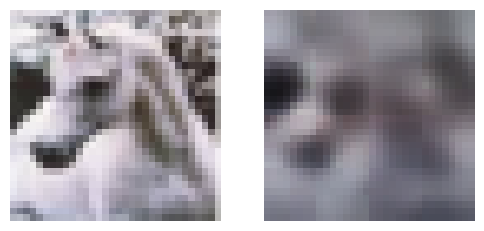

In [ ]:
plot_reconstruction_conv(conv_ae, valid_dataset, 5)

In [57]:
cls_conv_model = EncoderCls(conv_ae.encoder, 10).to(device)

restricted_loader = DataLoader(RestrictedDataset(train_dataset, 500), batch_size=32, shuffle=True)
nadam = torch.optim.NAdam(params=cls_conv_model.parameters())
accuracy = torchmetrics.Accuracy(task='multiclass', num_classes=10).to(device)
xentropy = nn.CrossEntropyLoss()

history = train_model(cls_conv_model, nadam, xentropy, accuracy, restricted_loader, cls_valid_loader, 500, train_encoder=False)

Epoch: 1/500	Train loss: 2.203	Train metrics: 0.188	Valid metrics: 0.104
Epoch: 2/500	Train loss: 1.939	Train metrics: 0.324	Valid metrics: 0.184
Epoch: 3/500	Train loss: 1.792	Train metrics: 0.408	Valid metrics: 0.240
Epoch: 4/500	Train loss: 1.713	Train metrics: 0.450	Valid metrics: 0.253
Epoch: 5/500	Train loss: 1.673	Train metrics: 0.452	Valid metrics: 0.170
Epoch: 6/500	Train loss: 1.611	Train metrics: 0.468	Valid metrics: 0.252
Epoch: 7/500	Train loss: 1.574	Train metrics: 0.490	Valid metrics: 0.198
Epoch: 8/500	Train loss: 1.514	Train metrics: 0.508	Valid metrics: 0.221
Epoch: 9/500	Train loss: 1.502	Train metrics: 0.520	Valid metrics: 0.264
Epoch: 10/500	Train loss: 1.423	Train metrics: 0.548	Valid metrics: 0.253
Epoch: 11/500	Train loss: 1.427	Train metrics: 0.532	Valid metrics: 0.272
Epoch: 12/500	Train loss: 1.401	Train metrics: 0.562	Valid metrics: 0.263
Epoch: 13/500	Train loss: 1.395	Train metrics: 0.534	Valid metrics: 0.264
Epoch: 14/500	Train loss: 1.382	Train metrics: 

# Ex2

2. Train a variational autoencoder on the image dataset of your choice, and use it to generate images. Alternatively, you can try to find an unlabeled dataset that you are interested in and see if you can generate new samples.

In [62]:
VAEOutput = namedtuple('VAEOutput', ['output', 'codings_mean', 'codings_logvar'])

class VAE(nn.Module):
    def __init__(self, codings_dim=128):
        super().__init__()
        self.encoder = nn.Sequential(nn.Flatten(), nn.Linear(3*32*32, 1024), nn.ReLU(),
                                     nn.Linear(1024, 512), nn.ReLU(),
                                     nn.Linear(512, 512), nn.ReLU(),
                                     nn.Linear(512, 2*codings_dim))
        
        self.decoder = nn.Sequential(nn.Linear(codings_dim, 512), nn.ReLU(),
                                     nn.Linear(512, 512), nn.ReLU(),
                                     nn.Linear(512, 1024), nn.ReLU(),
                                     nn.Linear(1024, 3*32*32), nn.Sigmoid(), nn.Unflatten(dim=1, unflattened_size=(3, 32, 32)))
        
    def encode(self, X):
        return self.encoder(X).chunk(2, dim=-1)
    
    def sample_codings(self, codings_mean, codings_logvar):
        codings_std = torch.exp(0.5*codings_logvar)
        noise = torch.randn_like(codings_std)
        return codings_mean + noise * codings_std
    
    def decode(self, X):
        return self.decoder(X)
    
    def forward(self, X):
        codings_mean, codings_logvar = self.encode(X)
        sampled_codings = self.sample_codings(codings_mean, codings_logvar)
        output = self.decode(sampled_codings)
        return VAEOutput(output, codings_mean, codings_logvar)
    
def vae_loss(y_pred, y_target, kl_weight=0.1):
    output, mean, logvar = y_pred
    kl_div = -0.5*torch.sum(1+logvar-logvar.exp()-mean.square(), dim=-1)
    return F.mse_loss(output, y_target) + kl_div.mean() * kl_weight / 3072

In [63]:
vae_model = VAE().to(device)

nadam = torch.optim.NAdam(vae_model.parameters())
rmse = torchmetrics.MeanSquaredError(squared=False).to(device)

history = train_model(vae_model, nadam, vae_loss, rmse, train_loader, valid_loader, 50)

Epoch: 1/50	Train loss: 0.045	Train metrics: 0.211	Valid metrics: 0.197
Epoch: 2/50	Train loss: 0.038	Train metrics: 0.194	Valid metrics: 0.194
Epoch: 3/50	Train loss: 0.035	Train metrics: 0.186	Valid metrics: 0.183
Epoch: 4/50	Train loss: 0.034	Train metrics: 0.182	Valid metrics: 0.182
Epoch: 5/50	Train loss: 0.033	Train metrics: 0.181	Valid metrics: 0.182
Epoch: 6/50	Train loss: 0.033	Train metrics: 0.181	Valid metrics: 0.182
Epoch: 7/50	Train loss: 0.033	Train metrics: 0.181	Valid metrics: 0.182
Epoch: 8/50	Train loss: 0.033	Train metrics: 0.180	Valid metrics: 0.181
Epoch: 9/50	Train loss: 0.033	Train metrics: 0.180	Valid metrics: 0.181
Epoch: 10/50	Train loss: 0.033	Train metrics: 0.180	Valid metrics: 0.181
Epoch: 11/50	Train loss: 0.033	Train metrics: 0.180	Valid metrics: 0.181
Epoch: 12/50	Train loss: 0.033	Train metrics: 0.180	Valid metrics: 0.181
Epoch: 13/50	Train loss: 0.033	Train metrics: 0.180	Valid metrics: 0.181
Epoch: 14/50	Train loss: 0.033	Train metrics: 0.180	Valid me

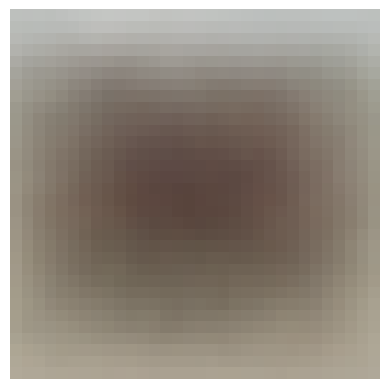

In [98]:
noise = torch.randn_like(torch.zeros([1, 128]))

vae_model.eval()
with torch.no_grad():
    output = vae_model.decode(noise.to(device))
    
output = output.cpu()
plt.imshow(output.view(3, 32, 32).permute(1, 2, 0))
plt.axis('off')
plt.show()